In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
import numpy as np
%matplotlib inline

In [2]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]


['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = []
for i in range(ord('a'), ord('z') + 1):
    print(chr(i), end=' ')
    chars.append(f"{chr(i)}")
stoi={}
stoi['.'] = 0
stoi|= {ch: i+1  for i, ch in enumerate(chars)}
itos = {i:ch for (ch, i) in stoi.items()}

a b c d e f g h i j k l m n o p q r s t u v w x y z 

In [114]:
# build the dataset
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    print(Xt.shape, Yt.shape)
    return Xt, Yt

# random shuffle
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtrain, Ytrain = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

torch.Size([182489, 3]) torch.Size([182489])
torch.Size([22856, 3]) torch.Size([22856])
torch.Size([22801, 3]) torch.Size([22801])


In [115]:
g = torch.Generator().manual_seed(2147483647)

# Hyperparams:
vocab_size = len(itos) # 27
n_embed = 10 # start with 2 for visualization purposes. 
n_hidden = 100


In [166]:
# Build a linear layer similar to pytorch. they use pytorch.tensor to hold values. 
class Linear:

    def __init__(self, fan_in: int , fan_out: int, bias=True, generator=g): 
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        self.bias = torch.randn(fan_out, generator=g) if bias else None

    def debug(self):
        print(f"weight({self.weight.shape}) and bias ({self.bias.shape})")

    def __call__(self, x):
        t = x @ self.weight
        # "is not" checks object memory
        if self.bias is not None:
            t += self.bias
        self.out = t
        return self.out

    def __repr__(self):
        return f"Linear:({self.weight.shape}) / ({None if self.bias is None else self.bias.shape})"

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


class Tanh():
        
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
        
    def parameters(self):
        return []
        
    def __repr__(self):
        return "Tanh()"

# BatchNorm has memory for parameter per neuron since we might want to move each neuron differently towards
# the edges of the activation function.
class BatchNorm1d:
    def __init__(self, layer_fanout, eps=1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = 0.1
        self.training = True
        self.gamma = torch.ones((1, layer_fanout))
        self.beta = torch.zeros((1, layer_fanout))

        self.running_mean = torch.zeros((1, layer_fanout))
        self.running_var = torch.ones((1, layer_fanout))
        

    def __call__(self, x):
        # (x - mean)/ std
        if self.training:
            mean = x.mean(0, keepdims=True)
            var = x.var(0, keepdims=True)
        else:
            mean = self.running_mean
            var = self.running_var
            
        tmp_out = (x - mean) / torch.sqrt(var + self.eps)

        self.out = tmp_out * self.gamma + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1.0 - self.momentum) * self.running_mean + self.momentum * mean
                self.running_var = (1.0 - self.momentum) * self.running_var + self.momentum * var
        
        return self.out

    def __repr__(self):
        return f"BN(gamma({self.gamma.shape}), beta({self.beta.shape})"
        
    def parameters(self):
        return [self.gamma, self.beta]
        


# c = Linear((block_size*n_embed), n_hidden, generator=g)
# c.debug()


# Embedding lookup table C
C = torch.randn((vocab_size, n_embed), generator=g)
layers = [
    Linear(block_size*n_embed, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]

# scale layer.weight by an appropriate factor.
with torch.no_grad():
    last_layer = layers[-1]
    if hasattr(last_layer, "weight"):
        last_layer.weight *= 0.1
    else:
        if hasattr(last_layer, "gamma"):
            last_layer.gamma *= 0.1
    for layer in layers:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

# set req grad for all parameters

parameters = [C] + [p for l in layers for p in l.parameters() ]
print(f"Number of parametes: {sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad = True

Number of parametes: 47024


In [171]:
# Forward pass, backward pass and update (grad)

lossi = []
stepi= []
lri = []
batch_size = 32
num_steps = 20000
ud = []

input_vector_size = block_size * n_embed
for i in range(num_steps):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    emb  = C[Xtrain[ix]]
    #print(emb.shape)
    out = emb.view(-1, input_vector_size)
    for l in layers:
        #print(f"layer {l}")
        out = l(out)
    logits = out

    loss = torch.nn.functional.cross_entropy(logits, Ytrain[ix])

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
        
    # zero grad
    
    for p in parameters:
        p.grad = None
        
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    # update the weights
    for p in parameters:
        p.data += (-lr * p.grad)
    lossi.append(loss)
    stepi.append(i)

    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i % 100 == 0:
        print(f"loss = {loss:.4f}")
    if i > 1:
        break  # for debug only.


loss = 3.3018


In [168]:
@torch.no_grad()
def split_loss(split):
    x, y = {
    'train': (Xtrain, Ytrain),
    'val': (Xdev, Ydev),
    'test': (Xtest, Ytest),
       }[split]
    emb = C[x] # (N, block_size, n_embd)
      # This is cool, wherever we have -1, its inferred from other dimensions.
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    out = embcat
    for l in layers:
        out = l(out)
    logits = out
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 3.291919708251953
val 3.2916243076324463


layer 2 (      Tanh): mean -0.00, std 0.63, saturated: 2.84%
layer 5 (      Tanh): mean +0.01, std 0.63, saturated: 2.59%
layer 8 (      Tanh): mean +0.00, std 0.64, saturated: 2.34%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.41%
layer 14 (      Tanh): mean -0.00, std 0.63, saturated: 2.94%


Text(0.5, 1.0, 'activation distribution')

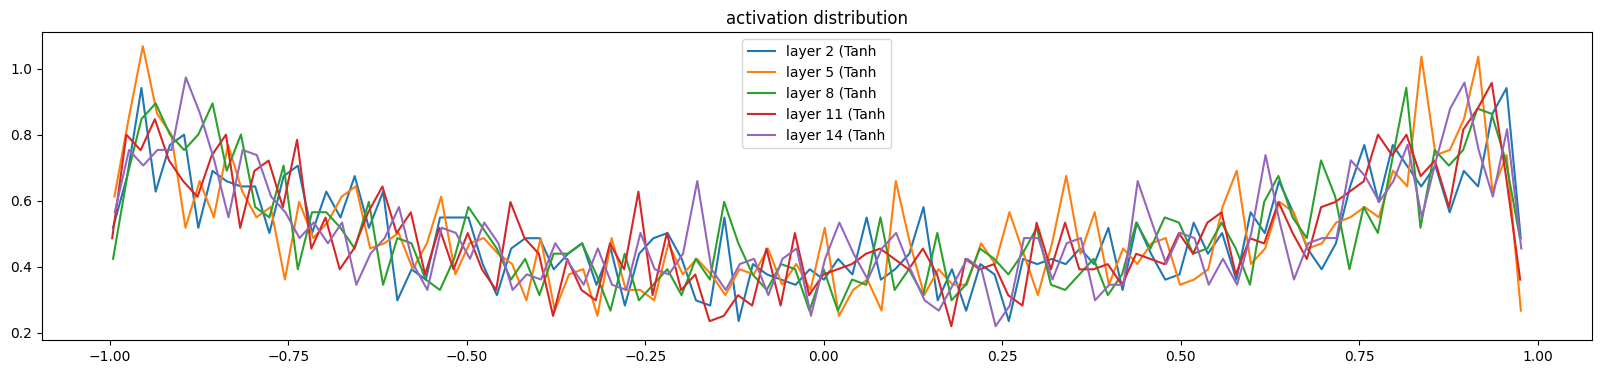

In [173]:
# visualize histograms of a activation values
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')

plt.legend(legends);
plt.title('activation distribution')

Tanh()
layer 2 (      Tanh): mean -0.000000, std 7.185332e-04 
Tanh()
layer 5 (      Tanh): mean -0.000000, std 6.585861e-04 
Tanh()
layer 8 (      Tanh): mean +0.000000, std 5.962626e-04 
Tanh()
layer 11 (      Tanh): mean +0.000000, std 5.511389e-04 
Tanh()
layer 14 (      Tanh): mean +0.000000, std 4.916284e-04 


Text(0.5, 1.0, 'gradients distribution')

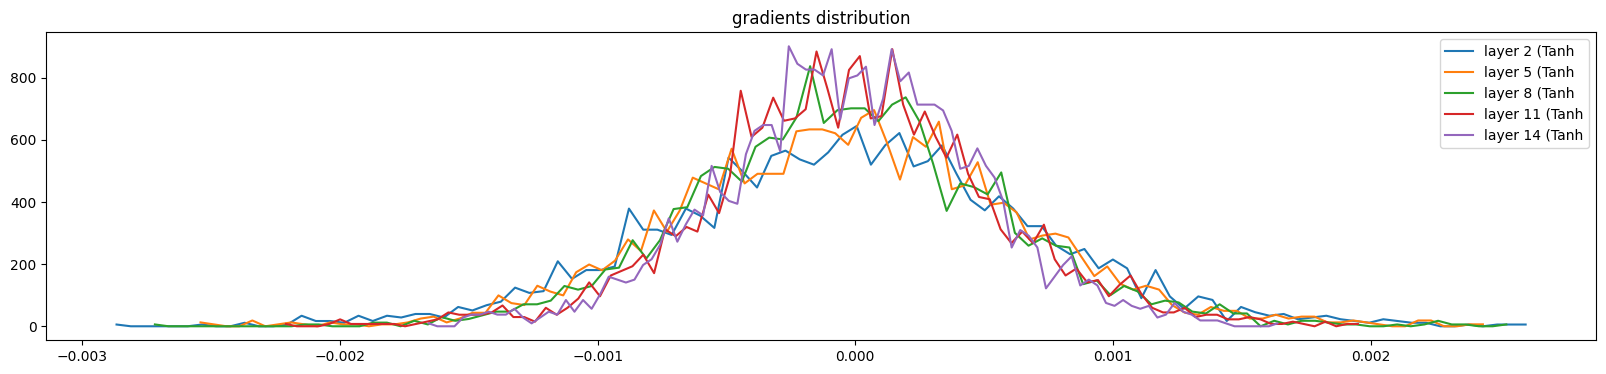

In [174]:
# visualize the gradients
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    print(f"{layer}")
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e ' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')

plt.legend(legends);
plt.title('gradients distribution')

weight   (27, 10) | mean +0.000000 | std 1.643131e-03 | grad:data ratio 1.632821e-03
weight  (30, 100) | mean +0.000029 | std 1.688808e-03 | grad:data ratio 5.432607e-03
weight (100, 100) | mean -0.000002 | std 1.544673e-03 | grad:data ratio 9.263153e-03
weight (100, 100) | mean +0.000003 | std 1.398059e-03 | grad:data ratio 8.373123e-03
weight (100, 100) | mean +0.000003 | std 1.280149e-03 | grad:data ratio 7.751727e-03
weight (100, 100) | mean -0.000015 | std 1.164609e-03 | grad:data ratio 6.962553e-03
weight  (100, 27) | mean -0.000009 | std 2.053519e-03 | grad:data ratio 1.244496e-02


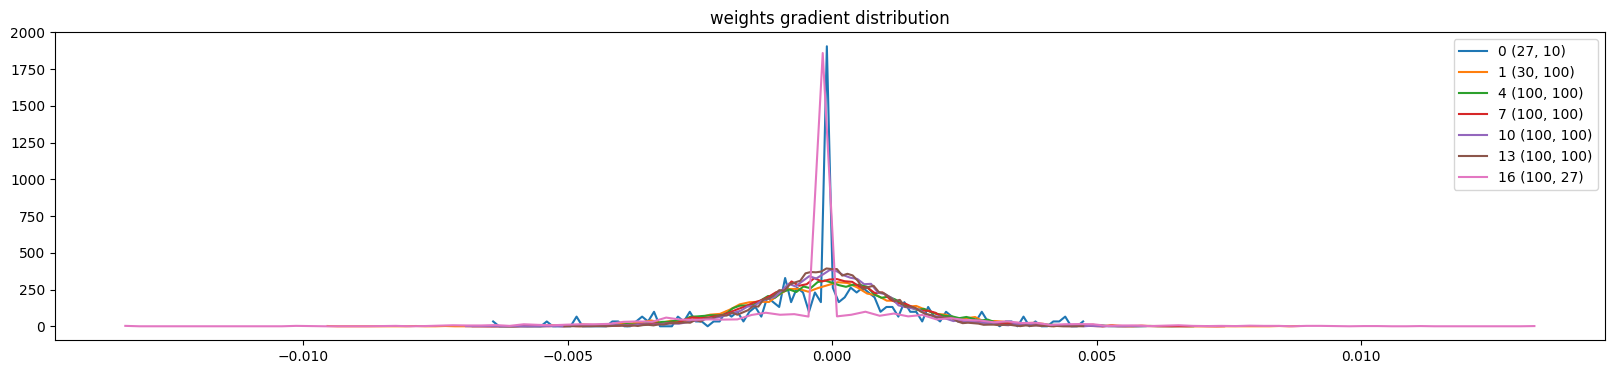

In [175]:
# visualize weights of linear layers
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2 and p.shape[0] != 1:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

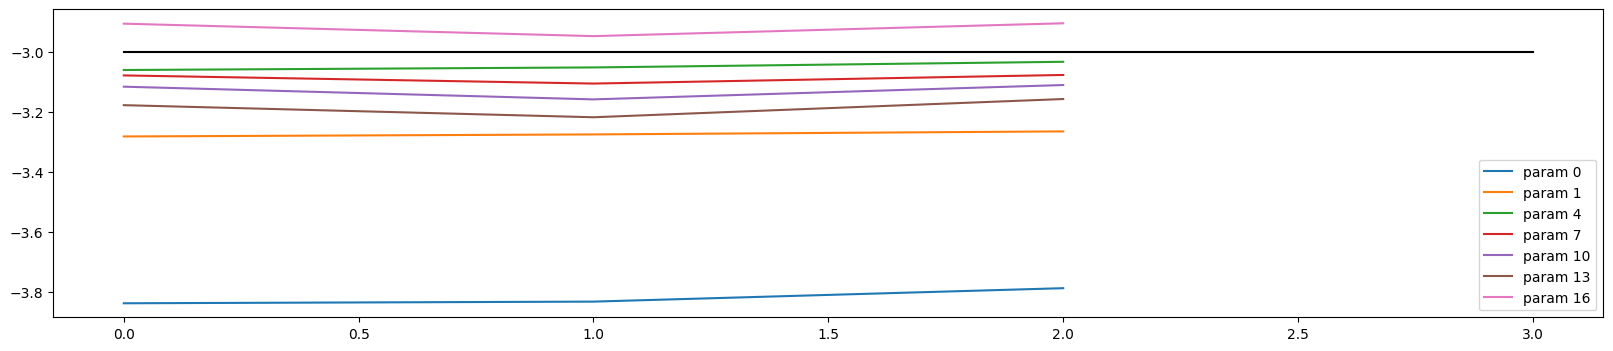

In [176]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2 and p.shape[0] != 1:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

interactive(children=(FloatSlider(value=0.0, description='x0', max=30.0, min=-30.0, step=0.5), Output()), _dom…

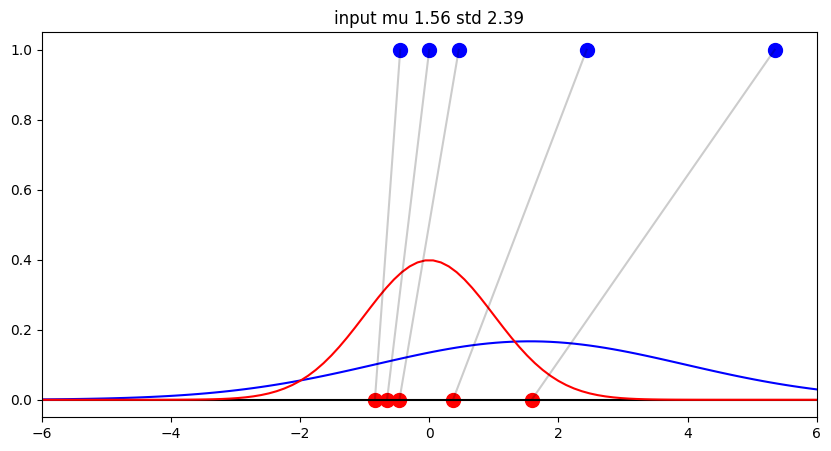

In [179]:
# More batchnorm experimentation

# BatchNorm forward pass as a widget

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
import scipy.stats as stats
import numpy as np

def normshow(x0):
  
  g = torch.Generator().manual_seed(2147483647+1)
  x = torch.randn(5, generator=g) * 5
  x[0] = x0 # override the 0th example with the slider
  mu = x.mean()
  sig = x.std()
  y = (x - mu)/sig

  plt.figure(figsize=(10, 5))
  # plot 0
  plt.plot([-6,6], [0,0], 'k')
  # plot the mean and std
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, mu, sig), 'b')
  xx = np.linspace(-6, 6, 100)
  plt.plot(xx, stats.norm.pdf(xx, 0, 1), 'r')
  # plot little lines connecting input and output
  for i in range(len(x)):
    plt.plot([x[i],y[i]], [1, 0], 'k', alpha=0.2)
  # plot the input and output values
  plt.scatter(x.data, torch.ones_like(x).data, c='b', s=100)
  plt.scatter(y.data, torch.zeros_like(y).data, c='r', s=100)
  plt.xlim(-6, 6)
  # title
  plt.title('input mu %.2f std %.2f' % (mu, sig))

interact(normshow, x0=(-30,30,0.5));

In [178]:
# Linear: activation statistics of forward and backward pass

g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a
loss = torch.randn(1000, generator=g) @ c
a.retain_grad()
b.retain_grad()
c.retain_grad()
loss.backward()
print('a std:', a.std().item())
print('b std:', b.std().item())
print('c std:', c.std().item())
print('-----')
print('c grad std:', c.grad.std().item())
print('a grad std:', a.grad.std().item())
print('b grad std:', b.grad.std().item())

a std: 0.9875972270965576
b std: 1.0006722211837769
c std: 31.01241683959961
-----
c grad std: 0.9782556295394897
a grad std: 30.8818302154541
b grad std: 0.9666601419448853


In [193]:
g = torch.Generator().manual_seed(2147483647)

a = torch.randn((1000,1), requires_grad=True, generator=g)          # a.grad = b.T @ c.grad
b = torch.randn((1000,1000), requires_grad=True, generator=g)       # b.grad = c.grad @ a.T
c = b @ a

In [182]:
c.shape

torch.Size([1000, 1])

In [194]:
t = torch.randn(1000, generator=g)
loss = t @ c
loss.shape, loss

(torch.Size([1]), tensor([43.6577], grad_fn=<SqueezeBackward4>))

In [201]:
a.retain_grad()
b.retain_grad()
c.retain_grad()

loss.backward()


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [204]:
c.grad.view(-1) == t
t.std(), t.mean()

(tensor(0.9783), tensor(0.0061))

In [ ]:
t[:10], c.grad.view(-1)[:10], t.shape, c.grad.shape